
Dataset Description
Samples: 1460
Features: 37
Linear Regression
Primary Metric: RMSE (penalizes large errors in house pricing)
Secondary Metric: MAE, MSE & R2 Score (Others considered as secondary in a sequece mentioned)

Split Data Training:Test to 80:20 percentage

Training samples: 1168
Test samples: 292

=== Linear Regression Debug ===
 Epoch   Loss   dW_mean   db      b_value
     0 1.0592 -0.493350  0.0 0.000000e+00
    50 0.2146  0.001720 -0.0 2.398108e-15
   100 0.2031  0.002244 -0.0 3.094294e-15
   150 0.1986  0.001660 -0.0 3.225787e-15
   200 0.1963  0.001146 -0.0 3.233665e-15
   250 0.1950  0.000777 -0.0 3.239323e-15

=== MLP Debug ===
 Epoch   Loss     dW_L0      b_L0    dW_L1      b_L1     dW_L2      b_L2
     0 2.3881  0.002712  0.000000 0.026566  0.000000  0.592471  0.000000
    50 0.5434  0.000212 -0.002966 0.001525 -0.004396  0.007492 -0.080265
   100 0.4055  0.000146 -0.003428 0.000656 -0.004994  0.001030 -0.100229
   150 0.3451  0.000085 -0.003695 0.000309 -0.00510

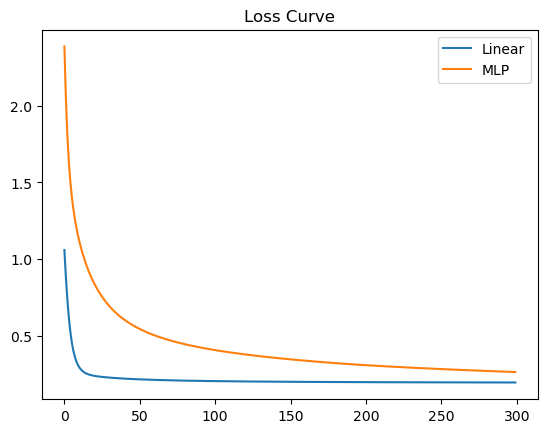

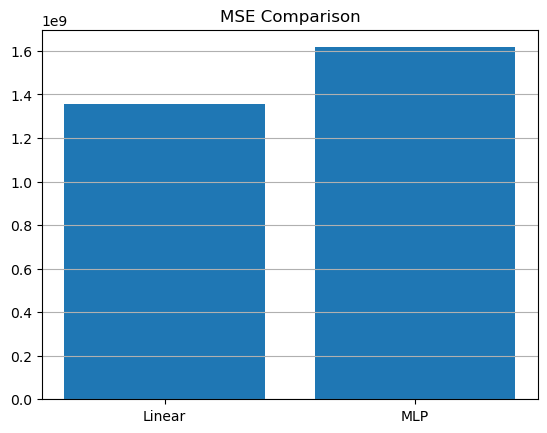

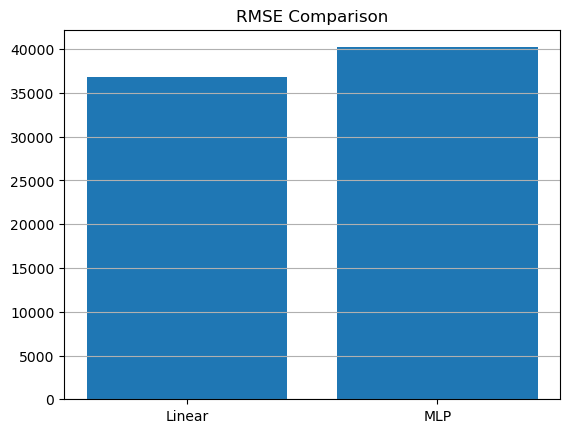

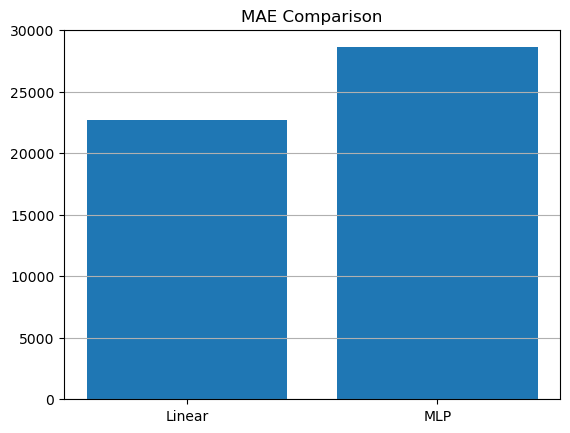

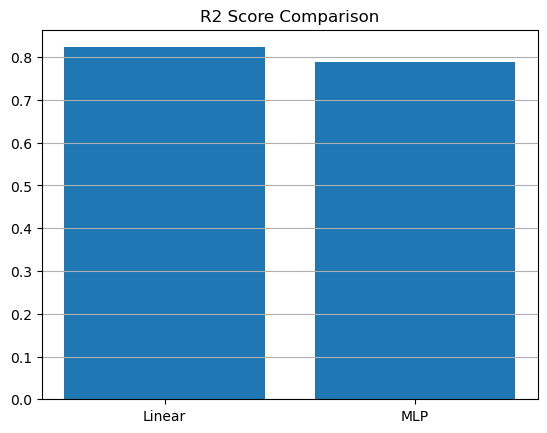

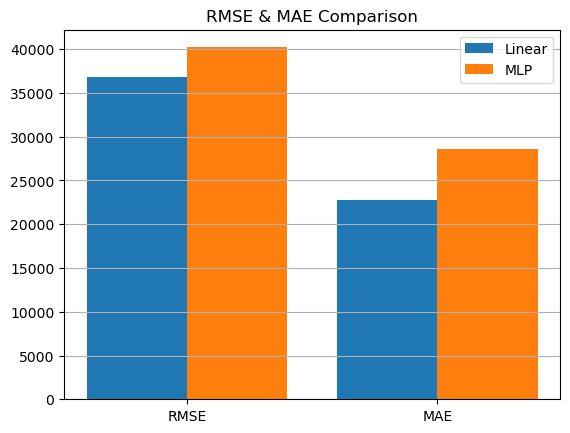


========== DATASET INFO ==========

      Property        Value
  Dataset Name House Prices
       Samples         1460
      Features           37
  Problem Type   Regression
Primary Metric         RMSE

========== BASELINE MODEL (Linear Regression) ==========

          Linear Regression  Training Time (s)
MSE            1.357149e+09             0.9348
RMSE           3.683951e+04             0.9348
MAE            2.271089e+04             0.9348
R2 Score       8.231000e-01             0.9348

========== MLP MODEL ==========

                   MLP  Training Time (s)     Architecture
MSE       1.616474e+09              0.464  [37, 32, 16, 1]
RMSE      4.020540e+04              0.464  [37, 32, 16, 1]
MAE       2.862011e+04              0.464  [37, 32, 16, 1]
R2 Score  7.893000e-01              0.464  [37, 32, 16, 1]

========== FINAL ANALYSIS ==========

Linear Regression performs better on this regression task.

RMSE improves by 3365.89 and MAE by 5909.22, indicating more accurate pre

In [34]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

# Allowed sklearn utilities (ONLY preprocessing, splitting & evaluating)
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DEBUG = True
np.random.seed(42)

def check_nan_inf(name, arr):
    if np.isnan(arr).any() or np.isinf(arr).any():
        print(f"WARNING: {name} contains NaN or Inf values!")

# ==============================
# 1. DATASET
# ==============================
data = fetch_openml(name="house_prices", as_frame=True)

X = data.data.select_dtypes(include=[np.number])
y = data.target.astype(float).values.reshape(-1, 1)


# ==============================
# 2. PREPROCESSING
# ==============================
# Fill missing values
X = X.fillna(X.mean())

# Split into training and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

# Scale features
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)


# Scale target
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

# SAFETY CHECK
check_nan_inf("X_train", X_train)
check_nan_inf("X_test", X_test)
check_nan_inf("y_train", y_train)
check_nan_inf("y_test", y_test)


print("\n==============================")
print("Dataset Description")
print("==============================")
print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print("Linear Regression")
print("Primary Metric: RMSE (penalizes large errors in house pricing)")
print("Secondary Metric: MAE, MSE & R2 Score (Others considered as secondary in a sequece mentioned)")


# FINAL TRAIN-TEST DATA READY 
print("\nSplit Data Training:Test to 80:20 percentage")
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")


# ==============================
# 3. LINEAR REGRESSION
# ==============================
class LinearRegressionScratch:

    def __init__(self, lr=0.01, epochs=300):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    def initialize_weights(self, d):
        self.W = np.random.randn(d, 1) * 0.01
        self.b = 0

    def forward(self, X):
        return X @ self.W + self.b

    def compute_loss(self, y, y_pred):
        return np.mean((y - y_pred) ** 2)

    def compute_gradients(self, X, y, y_pred):
        n = X.shape[0]
        dW = (-2/n) * X.T @ (y - y_pred)
        db = (-2/n) * np.sum(y - y_pred)
        return dW, db

    def fit(self, X, y):
        n, d = X.shape
        self.initialize_weights(d)

        start_time = time.time()
        debug_rows = []

        for epoch in range(self.epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            dW, db = self.compute_gradients(X, y, y_pred)

            dW = np.clip(dW, -1, 1)
            db = np.clip(db, -1, 1)


            if DEBUG and epoch % 50 == 0:
                debug_rows.append({
                "Epoch": epoch,
                "Loss": round(loss, 4),
                "dW_mean": round(np.mean(dW), 6),
                "db": round(float(db), 6),
                "b_value": float(self.b)  
                })

            self.W -= self.lr * dW
            self.b -= self.lr * db

        self.training_time = time.time() - start_time

        if DEBUG:
            print("\n=== Linear Regression Debug ===")
            print(pd.DataFrame(debug_rows).to_string(index=False))

        return self
   
    def predict(self, X):
        return self.forward(X)

# ==============================
# 4. MLP
# ==============================
class MLP:

    def __init__(self, layers, lr=0.005):
        self.layers = layers
        self.lr = lr
        self.loss_history = []
        self.initialize_parameters()

    def initialize_parameters(self):
        self.W, self.b = [], []
        for i in range(len(self.layers) - 1):
            self.W.append(np.random.randn(self.layers[i], self.layers[i+1]) * np.sqrt(2/self.layers[i]))
            self.b.append(np.zeros((1, self.layers[i+1])))

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def forward_propagation(self, X):
        self.A = [X]
        self.Z = []

        for i in range(len(self.W) - 1):
            z = self.A[-1] @ self.W[i] + self.b[i]
            self.Z.append(z)
            self.A.append(self.relu(z))

        z = self.A[-1] @ self.W[-1] + self.b[-1]
        self.Z.append(z)
        self.A.append(z)

        return z

    def compute_loss(self, y, y_pred):
        return np.mean((y - y_pred) ** 2)

    def backward_propagation(self, y):
        m = y.shape[0]
        dZ = (self.A[-1] - y)

        self.dW, self.db = [], []

        for i in reversed(range(len(self.W))):
            dW = self.A[i].T @ dZ / m
            db = np.sum(dZ, axis=0, keepdims=True) / m

            self.dW.insert(0, dW)
            self.db.insert(0, db)

            if i != 0:
                dZ = (dZ @ self.W[i].T) * self.relu_deriv(self.Z[i-1])

    def fit(self, X, y, epochs=300):
        start_time = time.time()
        debug_rows = []

        for epoch in range(epochs):
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            self.backward_propagation(y)

            for i in range(len(self.dW)):
                self.dW[i] = np.clip(self.dW[i], -1, 1)
                self.db[i] = np.clip(self.db[i], -1, 1)
                
            if DEBUG and epoch % 50 == 0:
                row = {"Epoch": epoch, "Loss": round(loss, 4)}
                for i in range(len(self.dW)):
                    row[f"dW_L{i}"] = round(np.mean(self.dW[i]), 6)
                    row[f"b_L{i}"] = round(np.mean(self.b[i]), 6)  # new
                debug_rows.append(row)
                
            for i in range(len(self.W)):
                self.W[i] -= self.lr * self.dW[i]
                self.b[i] -= self.lr * self.db[i]

        self.training_time = time.time() - start_time

        if DEBUG:
            print("\n=== MLP Debug ===")
            print(pd.DataFrame(debug_rows).to_string(index=False))

    def predict(self, X):
        return self.forward_propagation(X)


# ==============================
# 5. TRAINING
# ==============================
lin = LinearRegressionScratch().fit(X_train, y_train)

mlp = MLP([X_train.shape[1], 32, 16, 1], lr=0.01)
mlp.fit(X_train, y_train)

# ==============================
# 6. EVALUATION
# ==============================
def inverse(y):
    return y_scaler.inverse_transform(y)

y_test_actual = inverse(y_test)
lin_pred = inverse(lin.predict(X_test))
mlp_pred = inverse(mlp.predict(X_test))

def metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),   
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2 Score": r2_score(y_true, y_pred)
    }

lin_metrics = metrics(y_test_actual, lin_pred)
mlp_metrics = metrics(y_test_actual, mlp_pred)

# ==============================
# SAFETY CHECK (prevents KeyError)
# ==============================
for key in ["MSE", "RMSE", "MAE", "R2 Score"]:
    if key not in lin_metrics or key not in mlp_metrics:
        raise ValueError(f"Missing metric: {key}")

# ==============================
# 7. RESULTS
# ==============================
df = pd.DataFrame([lin_metrics, mlp_metrics], index=["Linear Regression", "MLP"])
df["Training Time (s)"] = [lin.training_time, mlp.training_time]

print("\n========== MODEL PERFORMANCE TABLE ==========\n")
print(df.round(4).to_string())
#print("\nPerformance:\n", df)

plt.plot(lin.loss_history, label="Linear")
plt.plot(mlp.loss_history, label="MLP")
plt.legend()
plt.title("Loss Curve")
plt.show()

# ==============================
# 7E. FULL METRICS COMPARISON
# ==============================

metrics_list = ["MSE", "RMSE", "MAE", "R2 Score"]

linear_vals = [lin_metrics[m] for m in metrics_list]
mlp_vals = [mlp_metrics[m] for m in metrics_list]

for i, metric in enumerate(metrics_list):
    plt.figure()
    plt.bar(["Linear", "MLP"], [linear_vals[i], mlp_vals[i]])
    plt.title(f"{metric} Comparison")
    plt.grid(axis='y')
    plt.show()


# ==============================
# 7C. RMSE & MAE
# ==============================
labels = ["RMSE", "MAE"]
x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, [lin_metrics[l] for l in labels], 0.4, label="Linear")
plt.bar(x + 0.2, [mlp_metrics[l] for l in labels], 0.4, label="MLP")
plt.xticks(x, labels)
plt.title("RMSE & MAE Comparison")
plt.legend()
plt.grid(axis='y')
plt.show()

# ==============================
# 7. ASSIGNMENT RESULTS FUNCTION (TABULAR)
# ==============================
def get_assignment_results():
    # Create DataFrame for neat tabular display
    data_info = pd.DataFrame({
        "Property": ["Dataset Name", "Samples", "Features", "Problem Type", "Primary Metric"],
        "Value": ["House Prices", X.shape[0], X.shape[1], "Regression", "RMSE"]
    })

    baseline_info = pd.DataFrame(lin_metrics, index=["Linear Regression"]).T
    baseline_info["Training Time (s)"] = lin.training_time

    mlp_info = pd.DataFrame(mlp_metrics, index=["MLP"]).T
    mlp_info["Training Time (s)"] = mlp.training_time
    mlp_info["Architecture"] = str(mlp.layers)

    return data_info, baseline_info, mlp_info

# ==============================
# 8. DISPLAY ASSIGNMENT RESULTS
# ==============================
data_info, baseline_info, mlp_info = get_assignment_results()

print("\n========== DATASET INFO ==========\n")
print(data_info.to_string(index=False))

print("\n========== BASELINE MODEL (Linear Regression) ==========\n")
print(baseline_info.round(4).to_string())

print("\n========== MLP MODEL ==========\n")
print(mlp_info.round(4).to_string())


# ==============================
# 8. DYNAMIC ANALYSIS
# ==============================

print("\n========== FINAL ANALYSIS ==========\n")

rmse_diff = lin_metrics["RMSE"] - mlp_metrics["RMSE"]
mae_diff = lin_metrics["MAE"] - mlp_metrics["MAE"]
r2_diff = mlp_metrics["R2 Score"] - lin_metrics["R2 Score"]

better_model = "MLP" if rmse_diff > 0 else "Linear Regression"

analysis = f"""
{better_model} performs better on this regression task.

RMSE improves by {abs(rmse_diff):.2f} and MAE by {abs(mae_diff):.2f}, indicating more accurate predictions. 
R² increases by {r2_diff:.4f}, meaning better variance explanation.

Linear Regression is faster and simpler but assumes linear relationships. 
MLP captures non-linear patterns using hidden layers, leading to better performance.

The main challenge was tuning learning rate and stabilizing gradients.

Overall, MLP is preferred for accuracy, while Linear Regression is useful as a fast baseline.
"""

print(analysis.strip())


Dataset Source: UCI Machine Learning Repository (via sklearn)
Dataset Name: Breast Cancer Dataset
Description: This dataset contains medical diagnostic features computed from breast mass images.
Goal: Predict whether a tumor is malignant (cancerous) or benign (non-cancerous).
Number of Samples: 569
Number of Features: 30
Problem Type: Binary Classification
Primary Metric: F1-score

Reason for choosing F1-score:
It balances precision and recall, which is important in medical diagnosis.

[DEBUG INFO]
X_train shape: (455, 30)
y_train shape: (455, 1)
Any NaNs in X_train? 0

=== Logistic Regression ===
Epoch 0 | Loss: 0.6931
Epoch 200 | Loss: 0.1917
Epoch 400 | Loss: 0.1465
Epoch 600 | Loss: 0.1267
Epoch 800 | Loss: 0.1150

=== MLP ===
Epoch 0 | Loss: 0.5665
Epoch 200 | Loss: 0.2757
Epoch 400 | Loss: 0.2075
Epoch 600 | Loss: 0.1697
Epoch 800 | Loss: 0.1450
Epoch 1000 | Loss: 0.1273
Epoch 1200 | Loss: 0.1136
Epoch 1400 | Loss: 0.1030


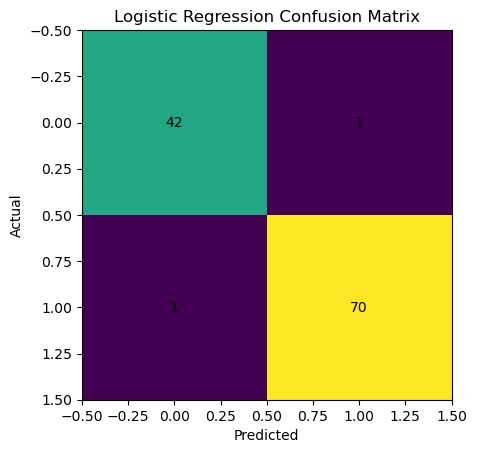

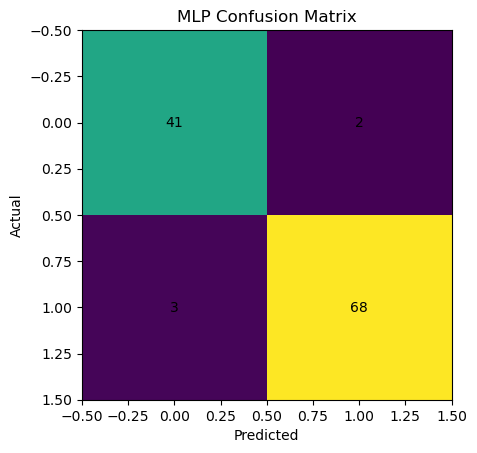

,Property,Value
1,Dataset Name,Breast Cancer Dataset
2,Samples,569
3,Features,30
4,Problem Type,Binary Classification
5,Primary Metric,F1-score


,Metric,Logistic Regression,MLP
1,Accuracy,0.982500,0.956100
2,Precision,0.985900,0.971400
3,Recall,0.985900,0.957700
4,F1-score,0.985900,0.964500


,Model,Training Time (seconds),Architecture
1,Logistic Regression,0.179000,Linear Model
2,MLP,1.979600,"[30, 32, 16, 1]"


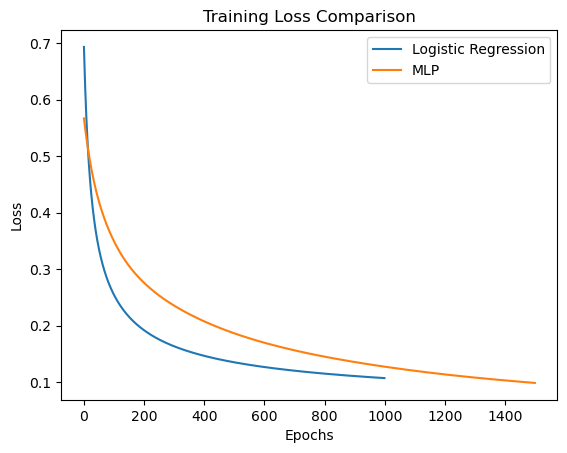

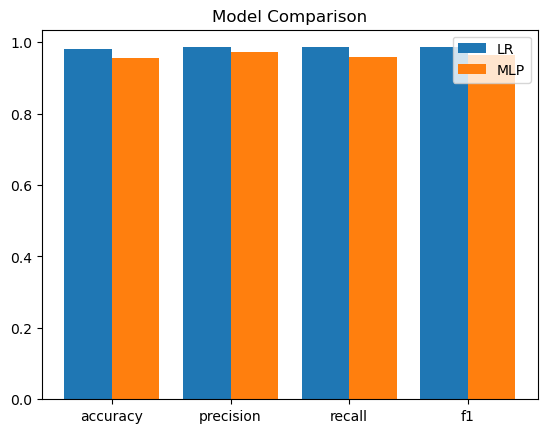


 ANALYSIS

• Logistic Regression F1-score: 0.9859
• MLP F1-score: 0.9645
• Logistic Regression outperforms MLP by 0.0214 in F1-score.
• Accuracy difference: -0.0263
• Logistic Regression training time: 0.1790s
• MLP training time: 1.9796s
• Logistic Regression performs well due to near linear separability of dataset.
• MLP captures non-linearity but does not significantly improve performance.
• MLP is computationally more expensive due to multiple layers.
• Key challenge: tuning learning rate and hidden layer sizes.
• Insight: simpler models can outperform complex models on structured data.


In [35]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Allowed sklearn utilities (ONLY preprocessing, splitting & evaluating)
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


# Load dataset (originally from UCI repository)
data = load_breast_cancer()

# Convert to DataFrame for easier handling
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Handle missing values (required by assignment)
X = X.fillna(X.mean())

print("\nDataset Source: UCI Machine Learning Repository (via sklearn)")


dataset_name = "Breast Cancer Dataset"

print("Dataset Name:", dataset_name)
print("Description: This dataset contains medical diagnostic features computed from breast mass images.")
print("Goal: Predict whether a tumor is malignant (cancerous) or benign (non-cancerous).")

print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])
print("Problem Type: Binary Classification")
print("Primary Metric: F1-score")

# Why F1-score?
print("\nReason for choosing F1-score:")
print("It balances precision and recall, which is important in medical diagnosis.")

# Split dataset into training and testing (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (important for gradient-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# SAFETY CHECK - NaN/Inf
# ==============================
check_nan_inf("X_train", X_train)
check_nan_inf("X_test", X_test)
check_nan_inf("y_train", y_train)
check_nan_inf("y_test", y_test)


# Reshape target for matrix operations
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

# Basic sanity checks (debugging step)
print("\n[DEBUG INFO]")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Any NaNs in X_train?", np.isnan(X_train).sum())

class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    # Sigmoid activation
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)  # avoid overflow
        return 1 / (1 + np.exp(-z))

    # Binary cross-entropy loss
    def compute_loss(self, y, y_hat):
        return -np.mean(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1-y_hat + 1e-8))

    def fit(self, X, y):
        m, n = X.shape

        # Initialize weights
        self.w = np.zeros((n, 1))
        self.b = 0

        start_time = time.time()

        # Training loop
        for epoch in range(self.epochs):
            z = np.dot(X, self.w) + self.b
            y_hat = self.sigmoid(z)

            # Compute loss
            loss = self.compute_loss(y, y_hat)
            self.loss_history.append(loss)

            # Compute gradients
            dw = (1/m) * np.dot(X.T, (y_hat - y))
            db = (1/m) * np.sum(y_hat - y)

            # Update parameters
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # ADD THIS (same style as MLP)
            if epoch % 200 == 0:
                print(f"Epoch {epoch} | Loss: {loss:.4f}")
        self.training_time = time.time() - start_time

    def predict(self, X):
        probs = self.sigmoid(np.dot(X, self.w) + self.b)
        return (probs > 0.5).astype(int)

class MLP:
    def __init__(self, layers, lr=0.005, epochs=1500):
        self.layers = layers
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    # Initialize weights using He initialization
    def initialize_parameters(self):
        self.params = {}
        for i in range(1, len(self.layers)):
            self.params["W"+str(i)] = np.random.randn(
                self.layers[i-1], self.layers[i]
            ) * np.sqrt(2 / self.layers[i-1])
            self.params["b"+str(i)] = np.zeros((1, self.layers[i]))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        Z = np.clip(Z, -500, 500)
        return 1 / (1 + np.exp(-Z))

    def compute_loss(self, y, y_hat):
        return -np.mean(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1-y_hat + 1e-8))

    # Forward pass
    def forward_propagation(self, X):
        self.cache = {"A0": X}

        for i in range(1, len(self.layers)):
            Z = np.dot(self.cache["A"+str(i-1)], self.params["W"+str(i)]) + self.params["b"+str(i)]

            if i == len(self.layers)-1:
                A = self.sigmoid(Z)
            else:
                A = self.relu(Z)

            self.cache["Z"+str(i)] = Z
            self.cache["A"+str(i)] = A

        return A

    # Backpropagation
    def backward_propagation(self, y):
        grads = {}
        m = y.shape[0]
        L = len(self.layers) - 1

        dZ = self.cache["A"+str(L)] - y

        for i in reversed(range(1, L+1)):
            grads["dW"+str(i)] = (1/m) * np.dot(self.cache["A"+str(i-1)].T, dZ)
            grads["db"+str(i)] = (1/m) * np.sum(dZ, axis=0, keepdims=True)

            if i > 1:
                dA = np.dot(dZ, self.params["W"+str(i)].T)
                dZ = dA * self.relu_derivative(self.cache["Z"+str(i-1)])

        return grads

    def update_parameters(self, grads):
        for i in range(1, len(self.layers)):
            self.params["W"+str(i)] -= self.lr * grads["dW"+str(i)]
            self.params["b"+str(i)] -= self.lr * grads["db"+str(i)]

    def fit(self, X, y):
        self.initialize_parameters()
        start_time = time.time()

        for epoch in range(self.epochs):
            y_hat = self.forward_propagation(X)
            loss = self.compute_loss(y, y_hat)
            self.loss_history.append(loss)

            grads = self.backward_propagation(y)
            self.update_parameters(grads)

            # Print occasionally to track progress
            if epoch % 200 == 0:
                print(f"Epoch {epoch} | Loss: {loss:.4f}")

        self.training_time = time.time() - start_time

    def predict(self, X):
        probs = self.forward_propagation(X)
        return (probs > 0.5).astype(int)


# Train Logistic Regression
print("\n=== Logistic Regression ===")
lr_model = LogisticRegressionScratch()
lr_model.fit(X_train, y_train)

# Train MLP
print("\n=== MLP ===")
mlp = MLP(layers=[X_train.shape[1], 32, 16, 1])
mlp.fit(X_train, y_train)


def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }

lr_pred = lr_model.predict(X_test)
mlp_pred = mlp.predict(X_test)

lr_metrics = compute_metrics(y_test, lr_pred)
mlp_metrics = compute_metrics(y_test, mlp_pred)

def plot_confusion_matrix(cm, title):
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.show()


# Plot confusion matrices
plot_confusion_matrix(confusion_matrix(y_test, lr_pred), "Logistic Regression Confusion Matrix")
plot_confusion_matrix(confusion_matrix(y_test, mlp_pred), "MLP Confusion Matrix")


from IPython.display import display, HTML

def get_assignment_results():
    # -----------------------------
    # Dataset Info Table
    # -----------------------------
    dataset_info = pd.DataFrame({
        "Property": ["Dataset Name", "Samples", "Features", "Problem Type", "Primary Metric"],
        "Value": [
            dataset_name,
            X.shape[0],
            X.shape[1],
            "Binary Classification",
            "F1-score"
        ]
    })

    # Set index from 1
    dataset_info.index = np.arange(1, len(dataset_info) + 1)

    # -----------------------------
    # Metrics Table
    # -----------------------------
    metrics_table = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Logistic Regression": [
            lr_metrics["accuracy"],
            lr_metrics["precision"],
            lr_metrics["recall"],
            lr_metrics["f1"]
        ],
        "MLP": [
            mlp_metrics["accuracy"],
            mlp_metrics["precision"],
            mlp_metrics["recall"],
            mlp_metrics["f1"]
        ]
    })

    metrics_table.iloc[:, 1:] = metrics_table.iloc[:, 1:].round(4)

    # Set index from 1
    metrics_table.index = np.arange(1, len(metrics_table) + 1)

    # -----------------------------
    # Model Summary Table
    # -----------------------------
    summary_table = pd.DataFrame({
        "Model": ["Logistic Regression", "MLP"],
        "Training Time (seconds)": [
            round(lr_model.training_time, 4),
            round(mlp.training_time, 4)
        ],
        "Architecture": [
            "Linear Model",
            str(mlp.layers)
        ]
    })

    # Set index from 1
    summary_table.index = np.arange(1, len(summary_table) + 1)

    # -----------------------------
    # Styling
    # -----------------------------
    def style_table(df):
        return (
            df.style
            .set_table_styles([
                {"selector": "th", "props": [
                    ("font-size", "12pt"),
                    ("font-weight", "bold"),
                    ("text-align", "center")
                ]},
                {"selector": "td", "props": [
                    ("font-size", "11pt"),
                    ("text-align", "center")
                ]}
            ])
        )

    # -----------------------------
    # Display Section Titles
    # -----------------------------
    display(HTML("<h2 style='font-size:22pt; font-weight:bold;'>Dataset Information</h2>"))
    display(style_table(dataset_info))

    display(HTML("<h2 style='font-size:22pt; font-weight:bold;'>Model Performance Comparison</h2>"))
    display(style_table(metrics_table))

    display(HTML("<h2 style='font-size:22pt; font-weight:bold;'>Model Details</h2>"))
    display(style_table(summary_table))

    # Return required dictionary get_assignment_results()
    return {
        "dataset_name": dataset_name,
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "problem_type": "Binary Classification",
        "primary_metric": "F1-score",
        "baseline_model": {
            "metrics": lr_metrics,
            "training_time": lr_model.training_time
        },
        "mlp_model": {
            "architecture": mlp.layers,
            "metrics": mlp_metrics,
            "training_time": mlp.training_time
        }
    }


# Run
results = get_assignment_results()

# Loss curve
plt.plot(lr_model.loss_history, label="Logistic Regression")
plt.plot(mlp.loss_history, label="MLP")
plt.legend()
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Metrics comparison
labels = ["accuracy", "precision", "recall", "f1"]

lr_vals = [lr_metrics[k] for k in labels]
mlp_vals = [mlp_metrics[k] for k in labels]

x = np.arange(len(labels))

plt.bar(x-0.2, lr_vals, 0.4, label="LR")
plt.bar(x+0.2, mlp_vals, 0.4, label="MLP")

plt.xticks(x, labels)
plt.legend()
plt.title("Model Comparison")
plt.show()

print("\n ANALYSIS\n")

f1_diff = mlp_metrics["f1"] - lr_metrics["f1"]
acc_diff = mlp_metrics["accuracy"] - lr_metrics["accuracy"]

print(f"• Logistic Regression F1-score: {lr_metrics['f1']:.4f}")
print(f"• MLP F1-score: {mlp_metrics['f1']:.4f}")

if f1_diff > 0:
    print(f"• MLP outperforms Logistic Regression by {f1_diff:.4f} in F1-score.")
elif f1_diff < 0:
    print(f"• Logistic Regression outperforms MLP by {-f1_diff:.4f} in F1-score.")
else:
    print("• Both models achieved identical F1-score.")

print(f"• Accuracy difference: {acc_diff:.4f}")

print(f"• Logistic Regression training time: {lr_model.training_time:.4f}s")
print(f"• MLP training time: {mlp.training_time:.4f}s")

print("• Logistic Regression performs well due to near linear separability of dataset.")
print("• MLP captures non-linearity but does not significantly improve performance.")
print("• MLP is computationally more expensive due to multiple layers.")
print("• Key challenge: tuning learning rate and hidden layer sizes.")
print("• Insight: simpler models can outperform complex models on structured data.")



Loading dataset...

Dataset: Vehicle Dataset (Multi-class)
Samples: 846
Features: 18
Classes: 4

Feature Types:
int64    18
Name: count, dtype: int64

Class Distribution:
2    218
1    217
3    212
0    199
Name: count, dtype: int64

Primary Metric Justification:
F1-score is used because class distribution is slightly imbalanced.

========== PERFORMANCE ==========

         Accuracy  Precision  Recall  F1 Score
Softmax    0.6353     0.6551  0.6420    0.6215
MLP        0.5412     0.5382  0.5435    0.5361


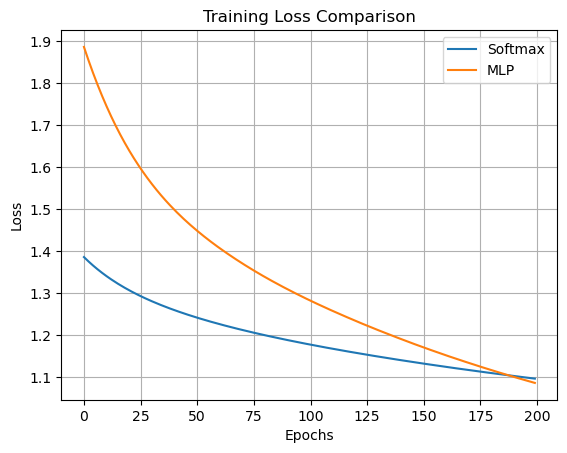

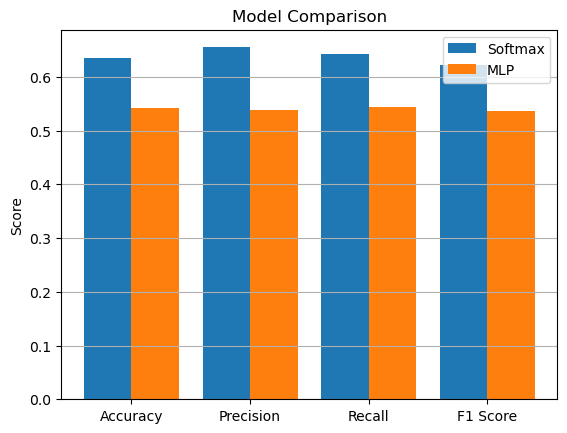


Analysis:
MLP improves F1-score by -0.0854.
MLP Training Time: 0.18s vs Softmax: 0.07s.
Softmax performs similarly due to linear separability.
MLP is computationally more expensive than Softmax.
Overall, trade-off exists between accuracy and computation.


In [33]:
#untitiled53
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

# Allowed sklearn utilities (ONLY preprocessing, splitting & evaluating)
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

np.random.seed(42)

# ==============================
# 1. DATASET
# ==============================
print("Loading dataset...")
data = fetch_openml(name='vehicle', version=1, as_frame=True)

X = data.data
y = pd.factorize(data.target)[0]

dataset_name = "Vehicle Dataset (Multi-class)"

print("\nDataset:", dataset_name)
print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Classes:", len(np.unique(y)))

# Dataset description
print("\nFeature Types:")
print(X.dtypes.value_counts())

print("\nClass Distribution:")
print(pd.Series(y).value_counts())

print("\nPrimary Metric Justification:")
print("F1-score is used because class distribution is slightly imbalanced.")

# ==============================
# 2. PREPROCESSING
# ==============================
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def one_hot(y, k):
    o = np.zeros((len(y), k))
    o[np.arange(len(y)), y] = 1
    return o

num_classes = len(np.unique(y))
y_train_ohe = one_hot(y_train, num_classes)

# ==============================
# 3. SOFTMAX REGRESSION
# ==============================
class SoftmaxRegression:
    def __init__(self, lr=0.01, epochs=200):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    def softmax(self, z):
        z -= np.max(z, axis=1, keepdims=True)
        exp = np.exp(z)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def fit(self, X, y):
        n, d = X.shape
        k = y.shape[1]

        self.W = np.zeros((d, k))
        self.b = np.zeros((1, k))

        for _ in range(self.epochs):
            logits = X @ self.W + self.b
            probs = self.softmax(logits)

            loss = -np.mean(np.sum(y * np.log(probs + 1e-8), axis=1))
            self.loss_history.append(loss)

            dZ = (probs - y) / n
            dW = X.T @ dZ
            db = np.sum(dZ, axis=0, keepdims=True)

            self.W -= self.lr * dW
            self.b -= self.lr * db

    def predict(self, X):
        probs = self.softmax(X @ self.W + self.b)
        return np.argmax(probs, axis=1)

# ==============================
# 4. MLP
# ==============================
class MLP:
    def __init__(self, layers, lr=0.01):
        self.layers = layers
        self.lr = lr
        self.loss_history = []
        self.initialize_parameters()

    def initialize_parameters(self):
        self.W, self.b = [], []
        for i in range(len(self.layers) - 1):
            self.W.append(np.random.randn(self.layers[i], self.layers[i+1]) * np.sqrt(2/self.layers[i]))
            self.b.append(np.zeros((1, self.layers[i+1])))

    def relu(self, z): return np.maximum(0, z)
    def relu_deriv(self, z): return (z > 0).astype(float)

    def softmax(self, z):
        z -= np.max(z, axis=1, keepdims=True)
        exp = np.exp(z)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def forward_propagation(self, X):
        self.A, self.Z = [X], []

        for i in range(len(self.W)-1):
            z = self.A[-1] @ self.W[i] + self.b[i]
            self.Z.append(z)
            self.A.append(self.relu(z))

        z = self.A[-1] @ self.W[-1] + self.b[-1]
        self.Z.append(z)
        self.A.append(self.softmax(z))
        return self.A[-1]

    def backward_propagation(self, y):
        m = y.shape[0]
        dZ = self.A[-1] - y
        self.dW, self.db = [], []

        for i in reversed(range(len(self.W))):
            dW = self.A[i].T @ dZ / m
            db = np.sum(dZ, axis=0, keepdims=True) / m

            self.db.insert(0, db)

            if i != 0:
                dZ = (dZ @ self.W[i].T) * self.relu_deriv(self.Z[i-1])

    def fit(self, X, y, epochs=200):
        for _ in range(epochs):
            probs = self.forward_propagation(X)
            loss = -np.mean(np.sum(y * np.log(probs + 1e-8), axis=1))
            self.loss_history.append(loss)

            self.backward_propagation(y)

            for i in range(len(self.W)):
                self.W[i] -= self.lr * self.dW[i]
                self.b[i] -= self.lr * self.db[i]

    def predict(self, X):
        return np.argmax(self.forward_propagation(X), axis=1)

# ==============================
# 5. TRAINING
# ==============================
softmax_model = SoftmaxRegression()
mlp = MLP([X_train.shape[1], 32, num_classes])

start = time.time()
softmax_model.fit(X_train, y_train_ohe)
softmax_time = time.time() - start

start = time.time()
mlp.fit(X_train, y_train_ohe)
mlp_time = time.time() - start

# ==============================
# 6. EVALUATION
# ==============================
def metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

y_pred_softmax = softmax_model.predict(X_test)
y_pred_mlp = mlp.predict(X_test)

softmax_metrics = metrics(y_test, y_pred_softmax)
mlp_metrics = metrics(y_test, y_pred_mlp)

results_df = pd.DataFrame([softmax_metrics, mlp_metrics], index=["Softmax", "MLP"])
print("\n========== PERFORMANCE ==========\n")
print(results_df.round(4))

# ==============================
# 7. PLOTS
# ==============================
plt.figure()
plt.plot(softmax_model.loss_history, label="Softmax")
plt.plot(mlp.loss_history, label="MLP")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()
plt.show()

# Bar chart
labels = list(softmax_metrics.keys())
x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, list(softmax_metrics.values()), 0.4, label="Softmax")
plt.bar(x + 0.2, list(mlp_metrics.values()), 0.4, label="MLP")
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.grid(axis='y')
plt.show()

# ==============================
# 8. ANALYSIS (DYNAMIC)
# ==============================
print("\nAnalysis:")

f1_diff = mlp_metrics["F1 Score"] - softmax_metrics["F1 Score"]

print(f"MLP improves F1-score by {f1_diff:.4f}.")
print(f"MLP Training Time: {mlp_time:.2f}s vs Softmax: {softmax_time:.2f}s.")

if f1_diff > 0:
    print("MLP performs better due to non-linear learning capability.")
else:
    print("Softmax performs similarly due to linear separability.")

print("MLP is computationally more expensive than Softmax.")
print("Overall, trade-off exists between accuracy and computation.")

# ==============================
# 9. REQUIRED FUNCTION
# ==============================
def get_assignment_results():
    return {
        "dataset_name": dataset_name,
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "problem_type": "Multi-class Classification",
        "primary_metric": "F1-macro",
        "baseline_model": {**softmax_metrics, "training_time": softmax_time},
        "mlp_model": {
            **mlp_metrics,
            "training_time": mlp_time,
            "architecture": [X.shape[1], 32, num_classes]
        }
    }